# Section 4: Discovered Equations and Process Interpretation
Process-level visualizations for each SR model.

In [2]:
import os
import json
import pickle
import warnings
import numpy as np
import pandas as pd
import xarray as xr
import proplot as pplt
from matplotlib.lines import Line2D
warnings.filterwarnings('ignore')
pplt.rc.update({
    'savefig.dpi':900,
    'savefig.bbox':'tight',
    'savefig.pad_inches':0.02,
    'tick.minor':False,
    'font.size':9,
    'label.size':9,
    'tick.labelsize':9,
    'title.size':9,
    'abc.size':9,
    'legend.fontsize':9,
    'suptitle.size':9,
    'leftlabelsize':9,
    'toplabelsize':9,
    'leftlabel.weight':'normal',
    'toplabel.weight':'normal',
    'reso':'xx-hi'})

In [3]:
with open('../scripts/configs.json','r',encoding='utf-8') as f:
    CONFIGS = json.load(f)
SPLITSDIR  = CONFIGS['filepaths']['splits']
WEIGHTSDIR = CONFIGS['filepaths']['weights']
PREDSDIR   = CONFIGS['filepaths']['predictions']
MODELSDIR  = CONFIGS['filepaths']['models']
FIELDVARS  = CONFIGS['experiments']['sr']['runs']['sr_atm']['fieldvars']
SEEDS      = CONFIGS['experiments']['nn']['seeds']
LATRANGE   = CONFIGS['domain']['latrange']
LONRANGE   = CONFIGS['domain']['lonrange']
SPLIT      = 'test'

SRMODELS   = CONFIGS['experiments']['sr']['optimizedeqs']
ALLMODELS  = {**CONFIGS['experiments']['nn']['runs'],**SRMODELS}

SRFUNCTIONS = {
    'cube':lambda x:x**3,'square':lambda x:x**2,'neg':lambda x:-x,
    'sqrt':np.sqrt,'exp':np.exp,'log':np.log,'abs':np.abs,
    'sin':np.sin,'cos':np.cos,'max':np.maximum,'min':np.minimum,
    '_safepow':lambda a,b:np.abs(a)**b}

import re
def _prepare_form(form):
    return re.sub(r'(\w+)\^(\w+)',r'_safepow(\1,\2)',form)

def eval_form(form,columns,constants):
    ns = dict(SRFUNCTIONS,__builtins__={})
    ns.update(columns)
    ns.update(constants)
    out = eval(_prepare_form(form),ns)
    if np.ndim(out)==0:
        n = len(next(v for v in columns.values() if hasattr(v,'__len__')))
        out = np.full(n,float(out))
    return np.asarray(out,dtype=float)

In [4]:
with open(os.path.join(SPLITSDIR,'stats.json'),'r',encoding='utf-8') as f:
    STATS = json.load(f)
MEAN = STATS['tp_mean']
STD  = STATS['tp_std']
ZMIN = (0.0 - MEAN) / STD

with xr.open_dataset(os.path.join(SPLITSDIR,f'norm_{SPLIT}.h5'),engine='h5netcdf') as ds:
    ntime = ds.sizes['time']
    nlat  = ds.sizes['lat']
    nlon  = ds.sizes['lon']
    nsig  = ds.sizes.get('sig',1)
    lat,lon = ds.lat.values,ds.lon.values
    dsig  = ds['dsig'].values
    fields = np.stack([ds[v].transpose('time','lat','lon','sig').values.reshape(-1,nsig) for v in FIELDVARS],axis=1)
    surfmask = ds['surfmask'].transpose('time','lat','lon','sig').values.reshape(-1,nsig) if 'surfmask' in ds else None
    flat = lambda v: ds[v].transpose('time','lat','lon').values.ravel() if 'time' in ds[v].dims else np.tile(ds[v].values,(ntime,1,1)).ravel()
    lfraw = flat('lf')
    shfraw = flat('shf')
    lhfraw = flat('lhf')
    blraw = flat('bl') if 'bl' in ds else np.zeros(ntime*nlat*nlon)

with xr.open_dataset(os.path.join(SPLITSDIR,f'{SPLIT}.h5'),engine='h5netcdf') as ds:
    obsraw = ds['tp'].transpose('time','lat','lon').values.ravel()
    months_all = np.repeat(ds.time.dt.month.values,nlat*nlon)

kernels = []
for seed in SEEDS:
    with xr.open_dataset(os.path.join(WEIGHTSDIR,f'nn_gauss_{seed}_weights.nc'),engine='h5netcdf') as ds:
        kernels.append(ds.k.values)
meankernel = np.mean(kernels,axis=0)
weighted = fields * meankernel[None,:,:] * dsig[None,None,:]
if surfmask is not None:
    weighted = weighted * surfmask[:,None,:]
integrals = weighted.sum(axis=2)
rhraw,thetaeraw,thetaestarraw = integrals[:,0],integrals[:,1],integrals[:,2]

valid = np.isfinite(rhraw) & np.isfinite(thetaeraw) & np.isfinite(thetaestarraw) & np.isfinite(obsraw)
rh,thetae,thetaestar = rhraw[valid],thetaeraw[valid],thetaestarraw[valid]
lf,shf,lhf = lfraw[valid],shfraw[valid],lhfraw[valid]
bl = blraw[valid]
obs = obsraw[valid]
months = months_all[valid]
lats = np.tile(lat[None,:,None],(ntime,1,nlon)).ravel()[valid]
lons = np.tile(lon[None,None,:],(ntime,nlat,1)).ravel()[valid]
landmask  = lf > 0.5
oceanmask = lf < 0.5

def to_map(flat):
    return np.nanmean(flat.reshape(ntime,nlat,nlon),axis=0)

print(f'Loaded {valid.sum():,} valid samples ({landmask.sum():,} land, {oceanmask.sum():,} ocean)')

Loaded 1,437,408 valid samples (428,352 land, 1,009,056 ocean)


In [5]:
regpath = os.path.join(MODELSDIR,'sr','optimized_equations.pkl')
with open(regpath,'rb') as f:
    REGISTRY = pickle.load(f)
ORDER = [name for name in SRMODELS if name in REGISTRY]
LABELS = {name:SRMODELS[name]['description'] for name in ORDER}
COLORS = {name:SRMODELS[name]['color'] for name in ORDER}
print(f'Loaded {len(ORDER)} optimized equations: {[LABELS[n] for n in ORDER]}')
for name in ORDER:
    entry = REGISTRY[name]
    print(f"  {LABELS[name]}: {entry['form']}  constants={entry['constants']}")

Loaded 4 optimized equations: ['SR-BL', 'SR-ATM', 'SR-SFC', 'SR-ALL']
  SR-BL: a*cube(bl+b)+c  constants={'a': 1.33, 'b': 0.63, 'c': -2.87}
  SR-ATM: a*cube(max(b*rh,c*thetae-d*thetaestar-e))  constants={'a': 0.07, 'b': 3.04, 'c': -3.24, 'd': 4.73, 'e': 5.24}
  SR-SFC: sr_atm_eq+a*shf*(b-lf)+c*lhf  constants={'a': -0.1, 'b': 3.42, 'c': 0.75}
  SR-ALL: sr_atm_eq+(a*thetae+b*shf)*cube(c-lf)+d  constants={'a': 0.68, 'b': 9.44, 'c': 0.81, 'd': 0.28}


In [6]:
def predict_eq(name,columns):
    entry = REGISTRY[name]
    form,constants = entry['form'],entry['constants']
    raw = eval_form(form,columns,constants)
    z = ZMIN + np.maximum(raw,0.0)
    return np.maximum(np.expm1(z * STD + MEAN),0.0)

def predict_eq_standardized(name,columns):
    entry = REGISTRY[name]
    form,constants = entry['form'],entry['constants']
    raw = eval_form(form,columns,constants)
    return ZMIN + np.maximum(raw,0.0)

def get_columns(**overrides):
    cols = {'rh':rh,'thetae':thetae,'thetaestar':thetaestar,'lf':lf,'shf':shf,'lhf':lhf,'bl':bl}
    cols.update(overrides)
    for eqname,entry in REGISTRY.items():
        if eqname in overrides:
            continue
        cols[eqname] = eval_form(entry['form'],cols,entry['constants'])
    return cols

COLS = get_columns()
MODELPRED = {name:predict_eq(name,COLS) for name in ORDER}
MODELPRED_Z = {name:predict_eq_standardized(name,COLS) for name in ORDER}

def get_r2(o,p):
    mask = np.isfinite(o)&np.isfinite(p)
    o,p = o[mask],p[mask]
    return 1-np.sum((o-p)**2)/np.sum((o-o.mean())**2)

def bin_1d(x,z,nbins=20,minsamples=50,plo=1,phi=99):
    mask = np.isfinite(x)&np.isfinite(z)
    x,z  = x[mask],z[mask]
    edges  = np.linspace(*np.percentile(x,[plo,phi]),nbins+1)
    xi     = np.clip(np.digitize(x,edges)-1,0,nbins-1)
    counts = np.bincount(xi,minlength=nbins)
    sums   = np.bincount(xi,weights=z,minlength=nbins)
    return 0.5*(edges[:-1]+edges[1:]),np.where(counts>=minsamples,sums/counts,np.nan),counts

def bin_2d(x,y,z,nbins=20,minsamples=50,plo=1,phi=99):
    mask  = np.isfinite(x)&np.isfinite(y)&np.isfinite(z)
    x,y,z = x[mask],y[mask],z[mask]
    xe = np.linspace(*np.percentile(x,[plo,phi]),nbins+1)
    ye = np.linspace(*np.percentile(y,[plo,phi]),nbins+1)
    xi = np.clip(np.digitize(x,xe)-1,0,nbins-1)
    yi = np.clip(np.digitize(y,ye)-1,0,nbins-1)
    idx    = xi*nbins+yi
    counts = np.bincount(idx,minlength=nbins*nbins).reshape(nbins,nbins)
    sums   = np.bincount(idx,weights=z,minlength=nbins*nbins).reshape(nbins,nbins)
    return (0.5*(xe[:-1]+xe[1:]),0.5*(ye[:-1]+ye[1:]),np.where(counts>=minsamples,sums/counts,np.nan),counts)

## 4.1 Partial Dependence Plots
For each SR model, show how predicted precipitation responds to each input variable
while holding the others at their median values.

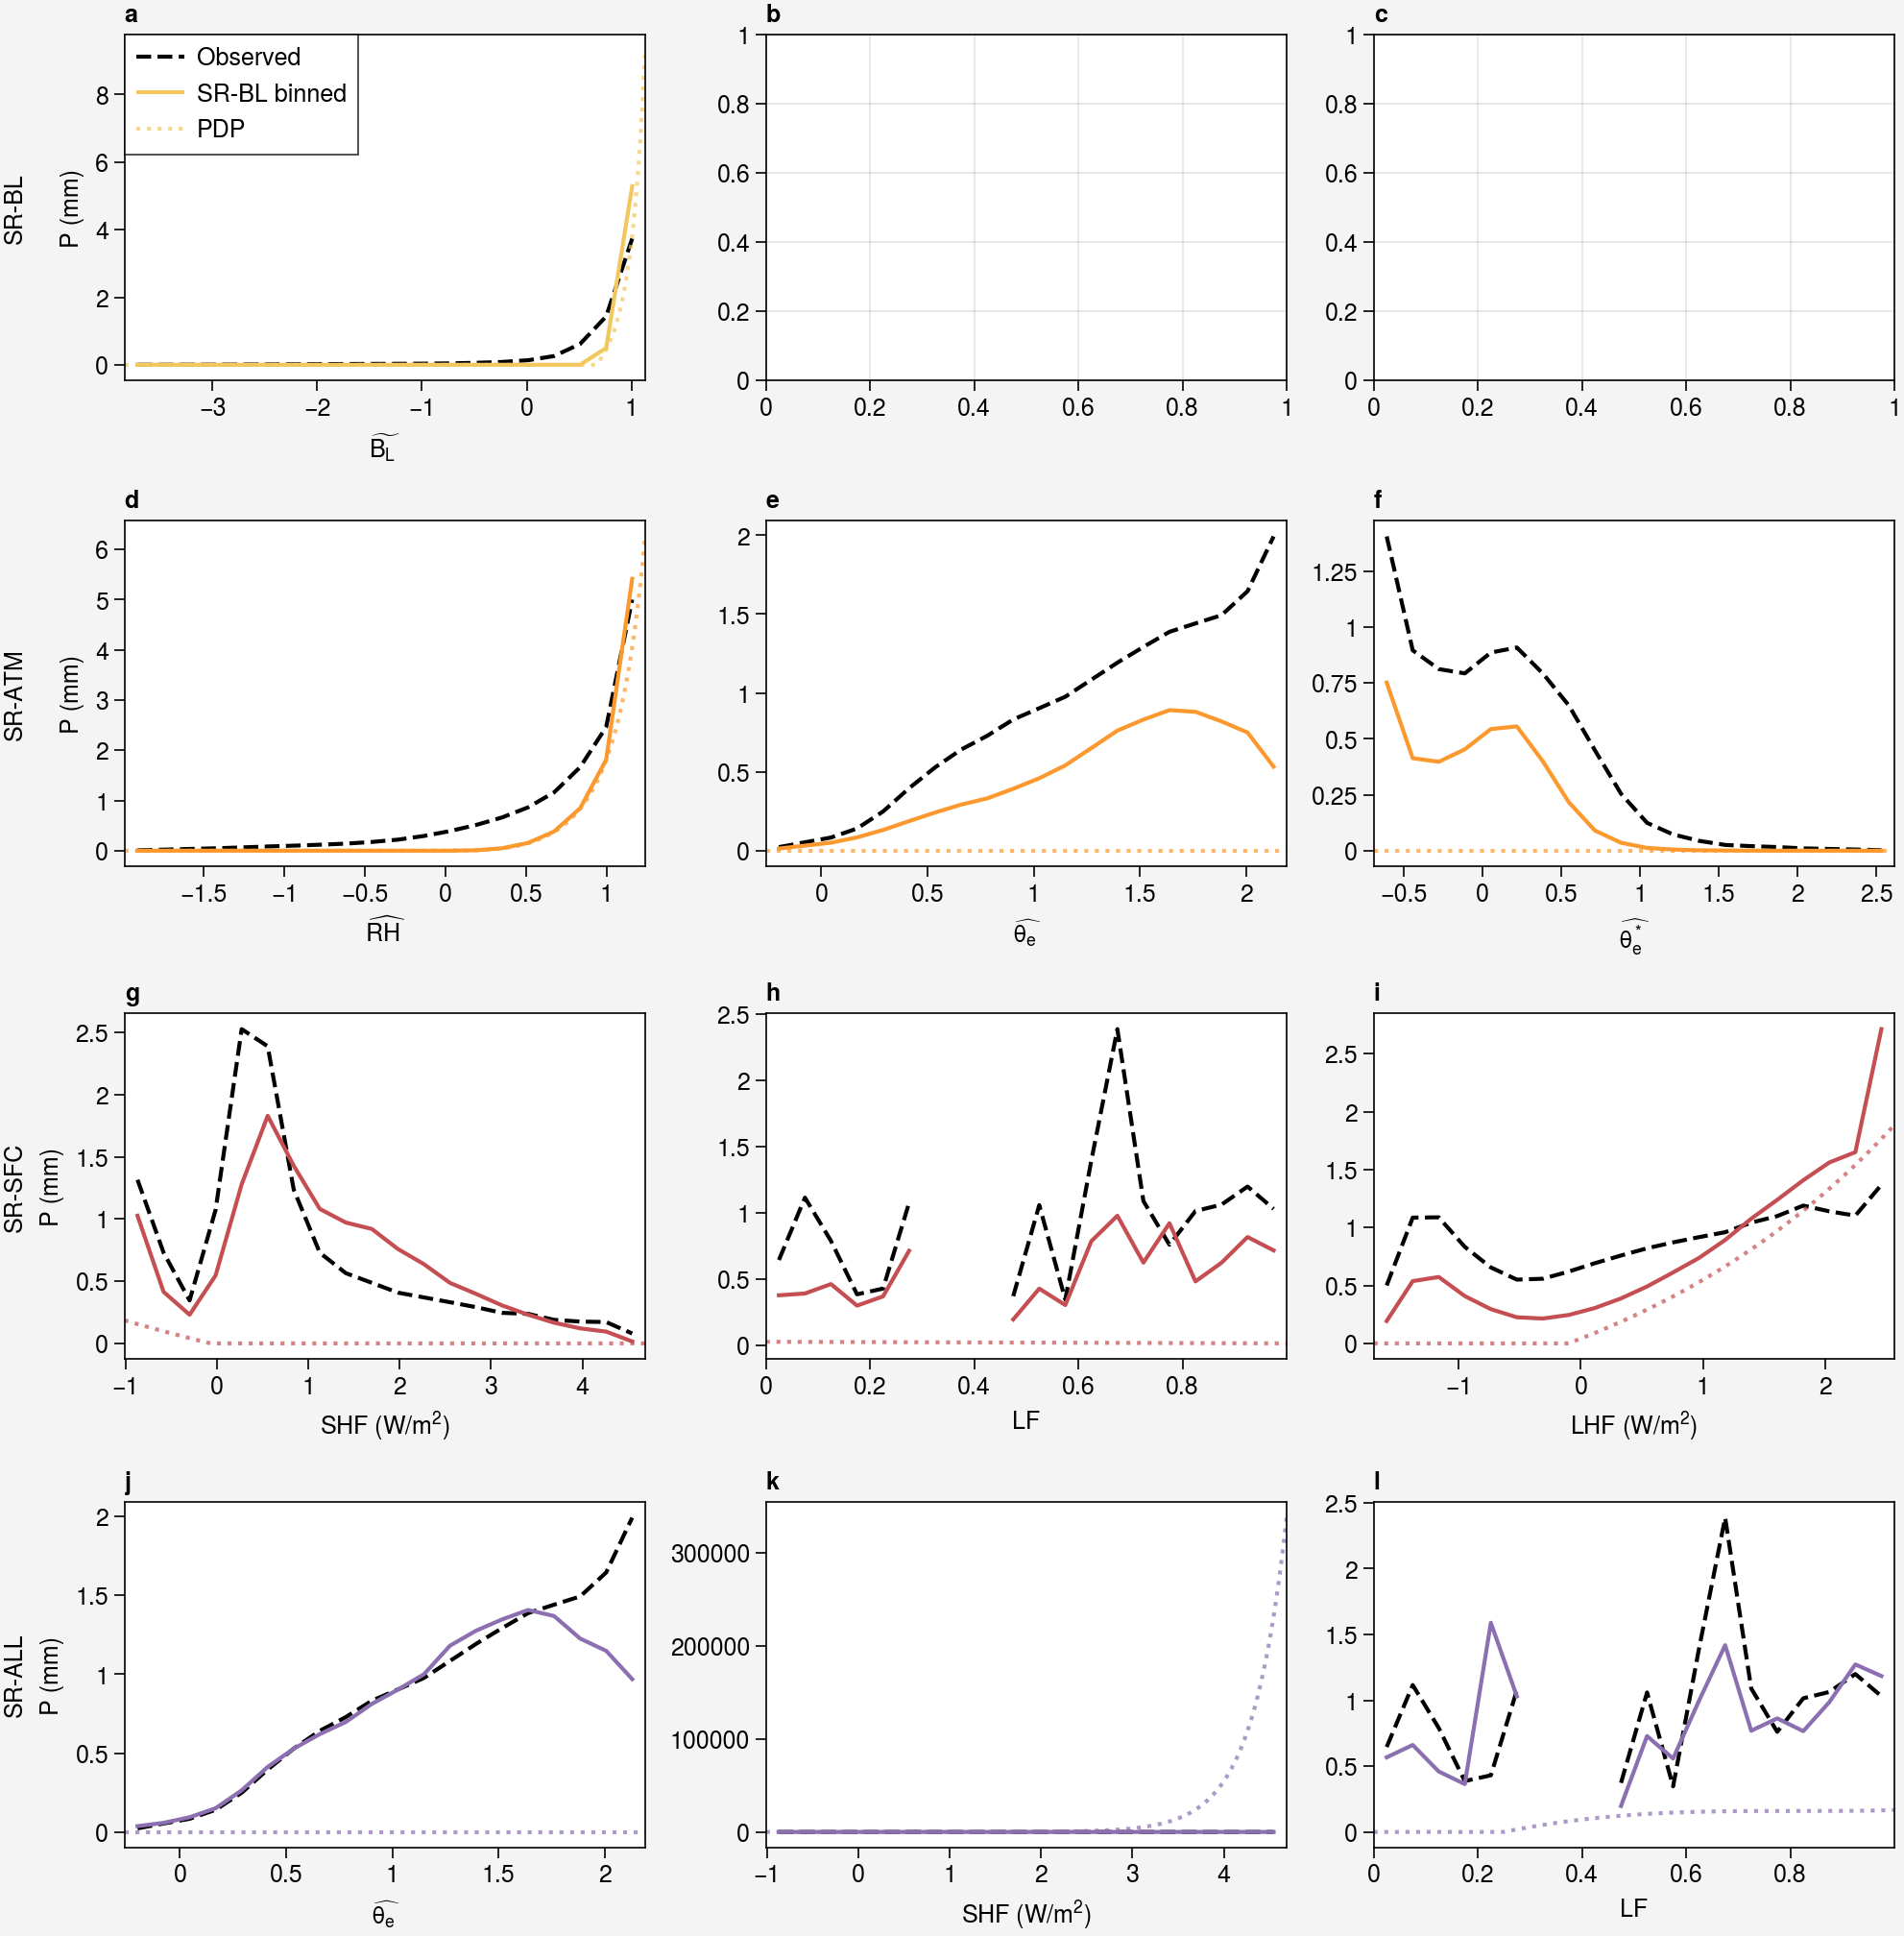

In [7]:
FEATLABELS = {
    'bl':r'$\widetilde{\mathrm{B_L}}$',
    'rh':r'$\widehat{\mathrm{RH}}$',
    'thetae':r'$\widehat{\theta_e}$',
    'thetaestar':r'$\widehat{\theta_e^*}$',
    'lf':'LF',
    'shf':'SHF (W/m$^2$)',
    'lhf':'LHF (W/m$^2$)'}

EQVARS = {
    'sr_bl_eq':['bl'],
    'sr_atm_eq':['rh','thetae','thetaestar'],
    'sr_sfc_eq':['shf','lf','lhf'],
    'sr_all_eq':['thetae','shf','lf']}

fig,axs = pplt.subplots(nrows=len(ORDER),ncols=3,figwidth=10,refheight=1.8,sharex=False,sharey=False)

for row,name in enumerate(ORDER):
    varlist = EQVARS[name]
    medians = {k:np.median(v) for k,v in COLS.items() if isinstance(v,np.ndarray)}
    for col,varkey in enumerate(varlist):
        ax = axs[row,col]
        xvals = np.linspace(np.percentile(COLS[varkey],1),np.percentile(COLS[varkey],99),200)
        overrides = {k:np.full_like(xvals,medians[k]) for k in medians if isinstance(medians[k],(float,np.floating))}
        overrides[varkey] = xvals
        pdcols = get_columns(**overrides)
        ypd = predict_eq(name,pdcols)
        centers,obsmean,_ = bin_1d(COLS[varkey],obs)
        _,predmean,_ = bin_1d(COLS[varkey],MODELPRED[name])
        ax.plot(centers,obsmean,color='k',linewidth=1.5,linestyle='--',label='Observed')
        ax.plot(centers,predmean,color=COLORS[name],linewidth=1.5,label=f'{LABELS[name]} binned')
        ax.plot(xvals,ypd,color=COLORS[name],linewidth=1.5,linestyle=':',alpha=0.7,label='PDP')
        ax.format(xlabel=FEATLABELS.get(varkey,varkey),ylabel='P (mm)' if col==0 else None,grid=False)
        if row==0 and col==0:
            ax.legend(loc='ul',ncols=1)

axs.format(abc=True,titleloc='l',
           rowlabels=[LABELS[n] for n in ORDER])
pplt.show()

## 4.2 Spatial Improvement Maps
Where does each model improve over SR-BL? Shows the reduction in squared error
relative to SR-BL at each grid cell (positive = improvement).

AttributeError: '_CartopyAxesSubplot' object has no attribute 'ndim'

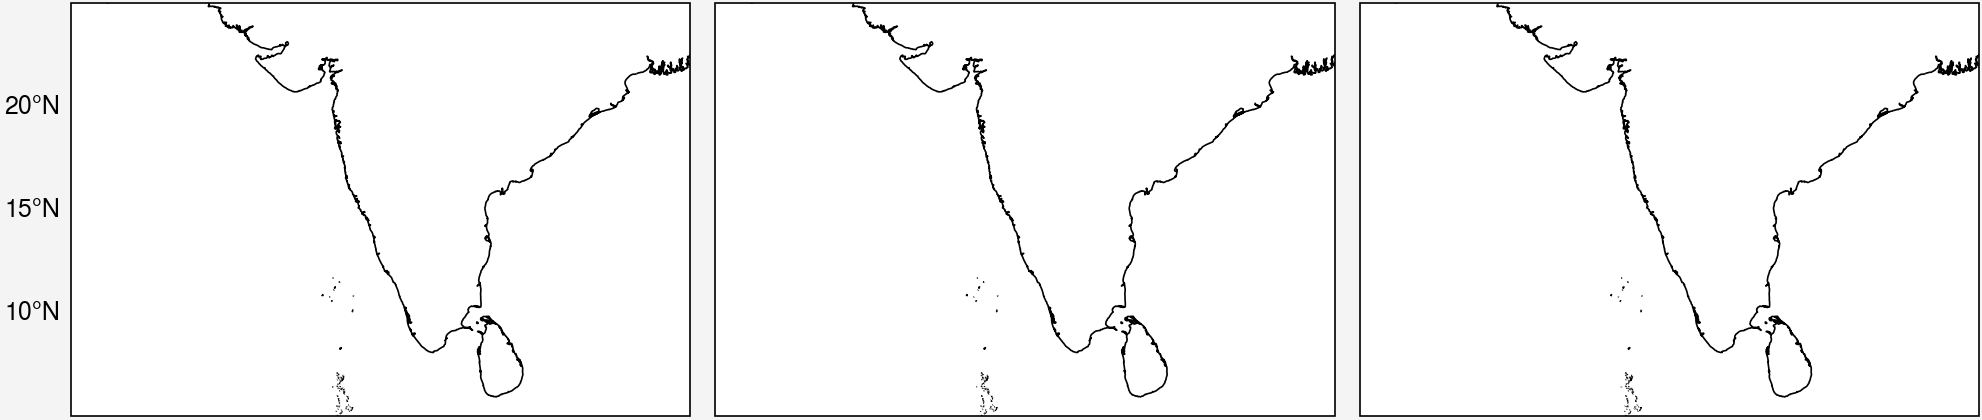

In [8]:
se_bl = (obsraw[valid] - MODELPRED['sr_bl_eq'])**2
se_bl_map = to_map(np.where(valid,np.nan,np.nan))  # placeholder

def se_map(pred):
    full = np.full_like(obsraw,np.nan)
    full[valid] = (obs - pred)**2
    return np.nanmean(full.reshape(ntime,nlat,nlon),axis=0)

mse_bl = se_map(MODELPRED['sr_bl_eq'])
obsvar = np.nanvar(obsraw.reshape(ntime,nlat,nlon),axis=0)

improvers = [n for n in ORDER if n != 'sr_bl_eq']
ncols = len(improvers)
fig,axs = pplt.subplots(ncols=ncols,proj='cyl',figwidth=10,share=True)
axs.format(coast=True,latlim=LATRANGE,lonlim=LONRANGE,
           latlines=[10,15,20],lonlines=[65,75,85],grid=False)
axs[:,0].format(latlabels='l')
axs[-1,:].format(lonlabels='b') if axs.ndim > 1 else axs.format(lonlabels='b')

m = None
for i,name in enumerate(improvers):
    mse_model = se_map(MODELPRED[name])
    skill_gain = 1 - mse_model / np.maximum(mse_bl,1e-12)
    m = axs[i].pcolormesh(lon,lat,skill_gain,cmap='ColdHot',vmin=-0.5,vmax=0.5,extend='both')
    axs[i].format(title=f'{LABELS[name]} vs SR-BL')

fig.colorbar(m,loc='b',label='Relative MSE Reduction (1 $-$ MSE$_{\mathrm{model}}$ / MSE$_{\mathrm{SR\text{-}BL}}$)')
axs.format(abc=True,titleloc='l')
pplt.show()

## 4.3 Moisture–Instability (M–I) Phase Space for SR-ATM
The SR-ATM equation `a*cube(max(rh, thetae - b*thetaestar - c))` implements a
moisture pathway (dominated by R̂H) and an instability pathway (dominated by
θ̂e − b·θ̂e*). This diagram shows which pathway controls precipitation
across the phase space.

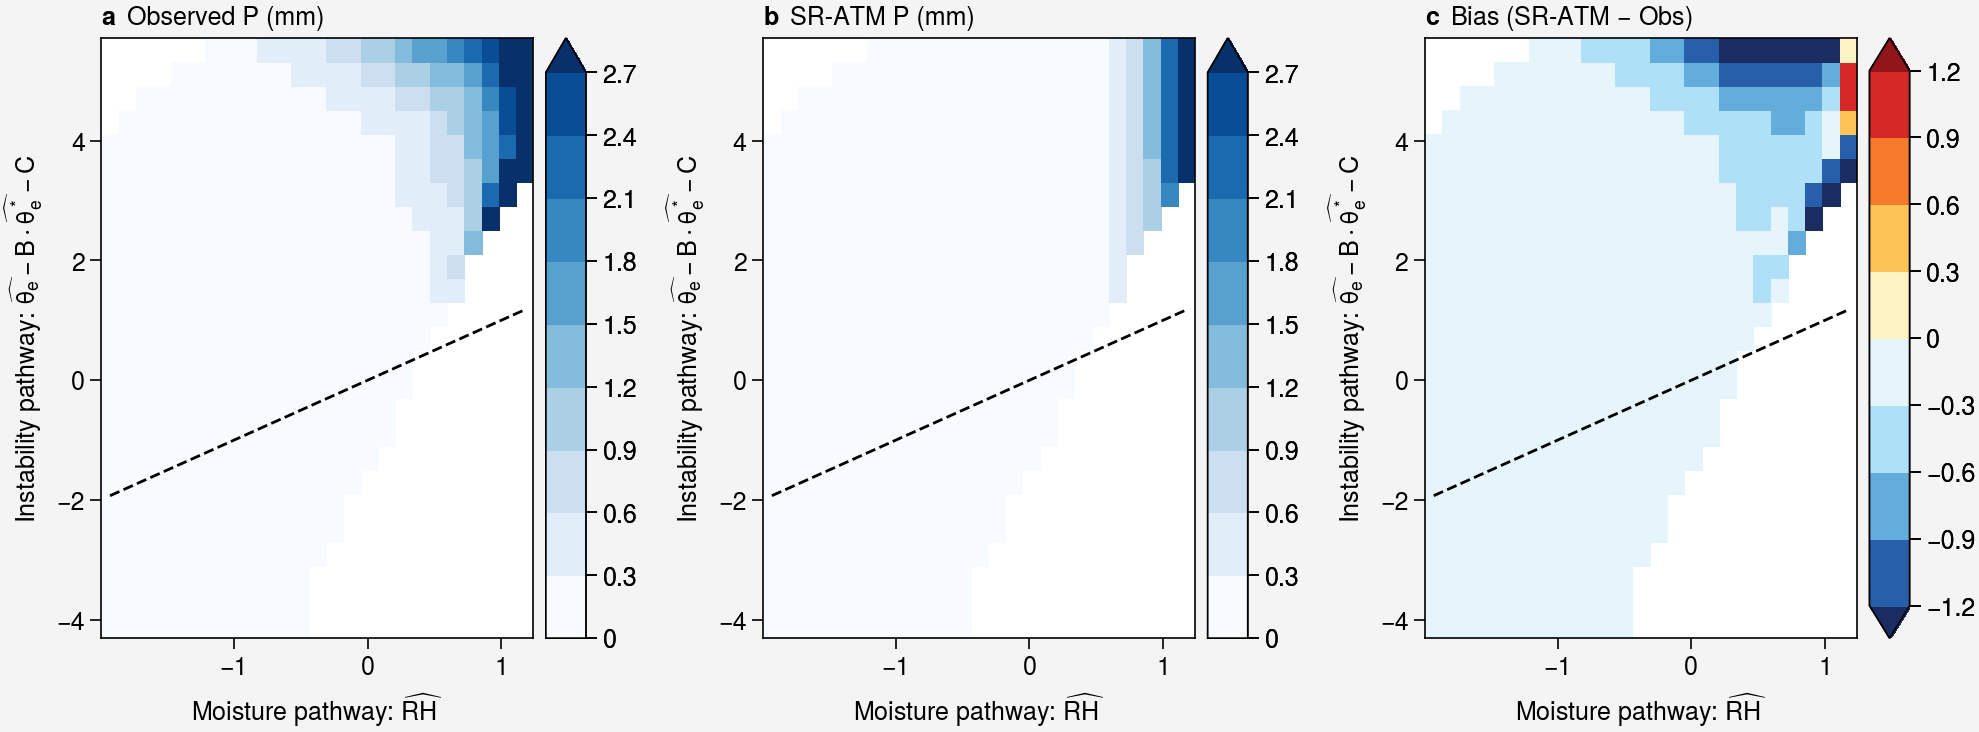

In [9]:
entry_atm = REGISTRY['sr_atm_eq']
ca = entry_atm['constants']
a_atm,b_atm,c_atm = ca['a'],ca['b'],ca['c']

moisture   = rh
instability = thetae - b_atm * thetaestar - c_atm
dominant    = np.where(moisture >= instability,'Moisture','Instability')

nbins = 25
mcenters,icenters,obsmean,counts = bin_2d(moisture,instability,obs,nbins=nbins)
_,_,predmean,_ = bin_2d(moisture,instability,MODELPRED['sr_atm_eq'],nbins=nbins)

fig,axs = pplt.subplots(ncols=3,figwidth=10,refheight=3,share=False)
axs.format(grid=False,
           xlabel=r'Moisture pathway: $\widehat{\mathrm{RH}}$',
           ylabel=r'Instability pathway: $\widehat{\theta_e} - B \cdot \widehat{\theta_e^*} - C$')

m1 = axs[0].pcolormesh(mcenters,icenters,obsmean.T,cmap='Blues',vmin=0,vmax=3,extend='max')
axs[0].plot([mcenters.min(),mcenters.max()],[mcenters.min(),mcenters.max()],color='k',linewidth=1,linestyle='--')
axs[0].format(title='Observed P (mm)')
axs[0].colorbar(m1,loc='r')

m2 = axs[1].pcolormesh(mcenters,icenters,predmean.T,cmap='Blues',vmin=0,vmax=3,extend='max')
axs[1].plot([mcenters.min(),mcenters.max()],[mcenters.min(),mcenters.max()],color='k',linewidth=1,linestyle='--')
axs[1].format(title='SR-ATM P (mm)')
axs[1].colorbar(m2,loc='r')

biasmean = predmean - obsmean
m3 = axs[2].pcolormesh(mcenters,icenters,biasmean.T,cmap='ColdHot',vmin=-1.5,vmax=1.5,extend='both')
axs[2].plot([mcenters.min(),mcenters.max()],[mcenters.min(),mcenters.max()],color='k',linewidth=1,linestyle='--')
axs[2].format(title='Bias (SR-ATM $-$ Obs)')
axs[2].colorbar(m3,loc='r')

axs.format(abc=True,titleloc='l')
pplt.show()

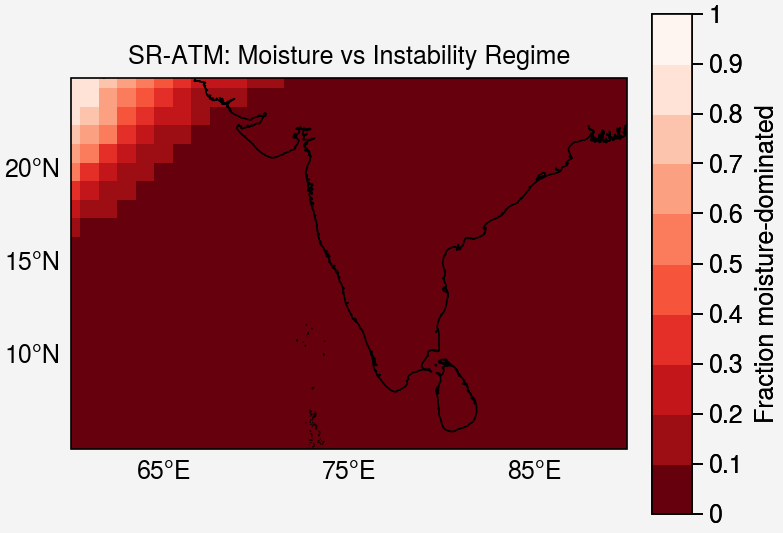

In [10]:
regime_full = np.full_like(obsraw,np.nan)
regime_full[valid] = np.where(dominant=='Moisture',1.0,0.0)
regime_map = to_map(regime_full)

fig,ax = pplt.subplots(proj='cyl',figwidth=4,refheight=2.5)
ax.format(coast=True,latlim=LATRANGE,lonlim=LONRANGE,
          latlines=[10,15,20],lonlines=[65,75,85],grid=False,
          latlabels='l',lonlabels='b')
m = ax.pcolormesh(lon,lat,regime_map,cmap='Reds_r',vmin=0,vmax=1)
fig.colorbar(m,loc='r',label='Fraction moisture-dominated')
ax.format(title='SR-ATM: Moisture vs Instability Regime')
pplt.show()

## 4.4 Surface Coupling Structure
How the surface flux correction terms in SR-SFC and SR-ALL modulate
the atmospheric baseline (SR-ATM).

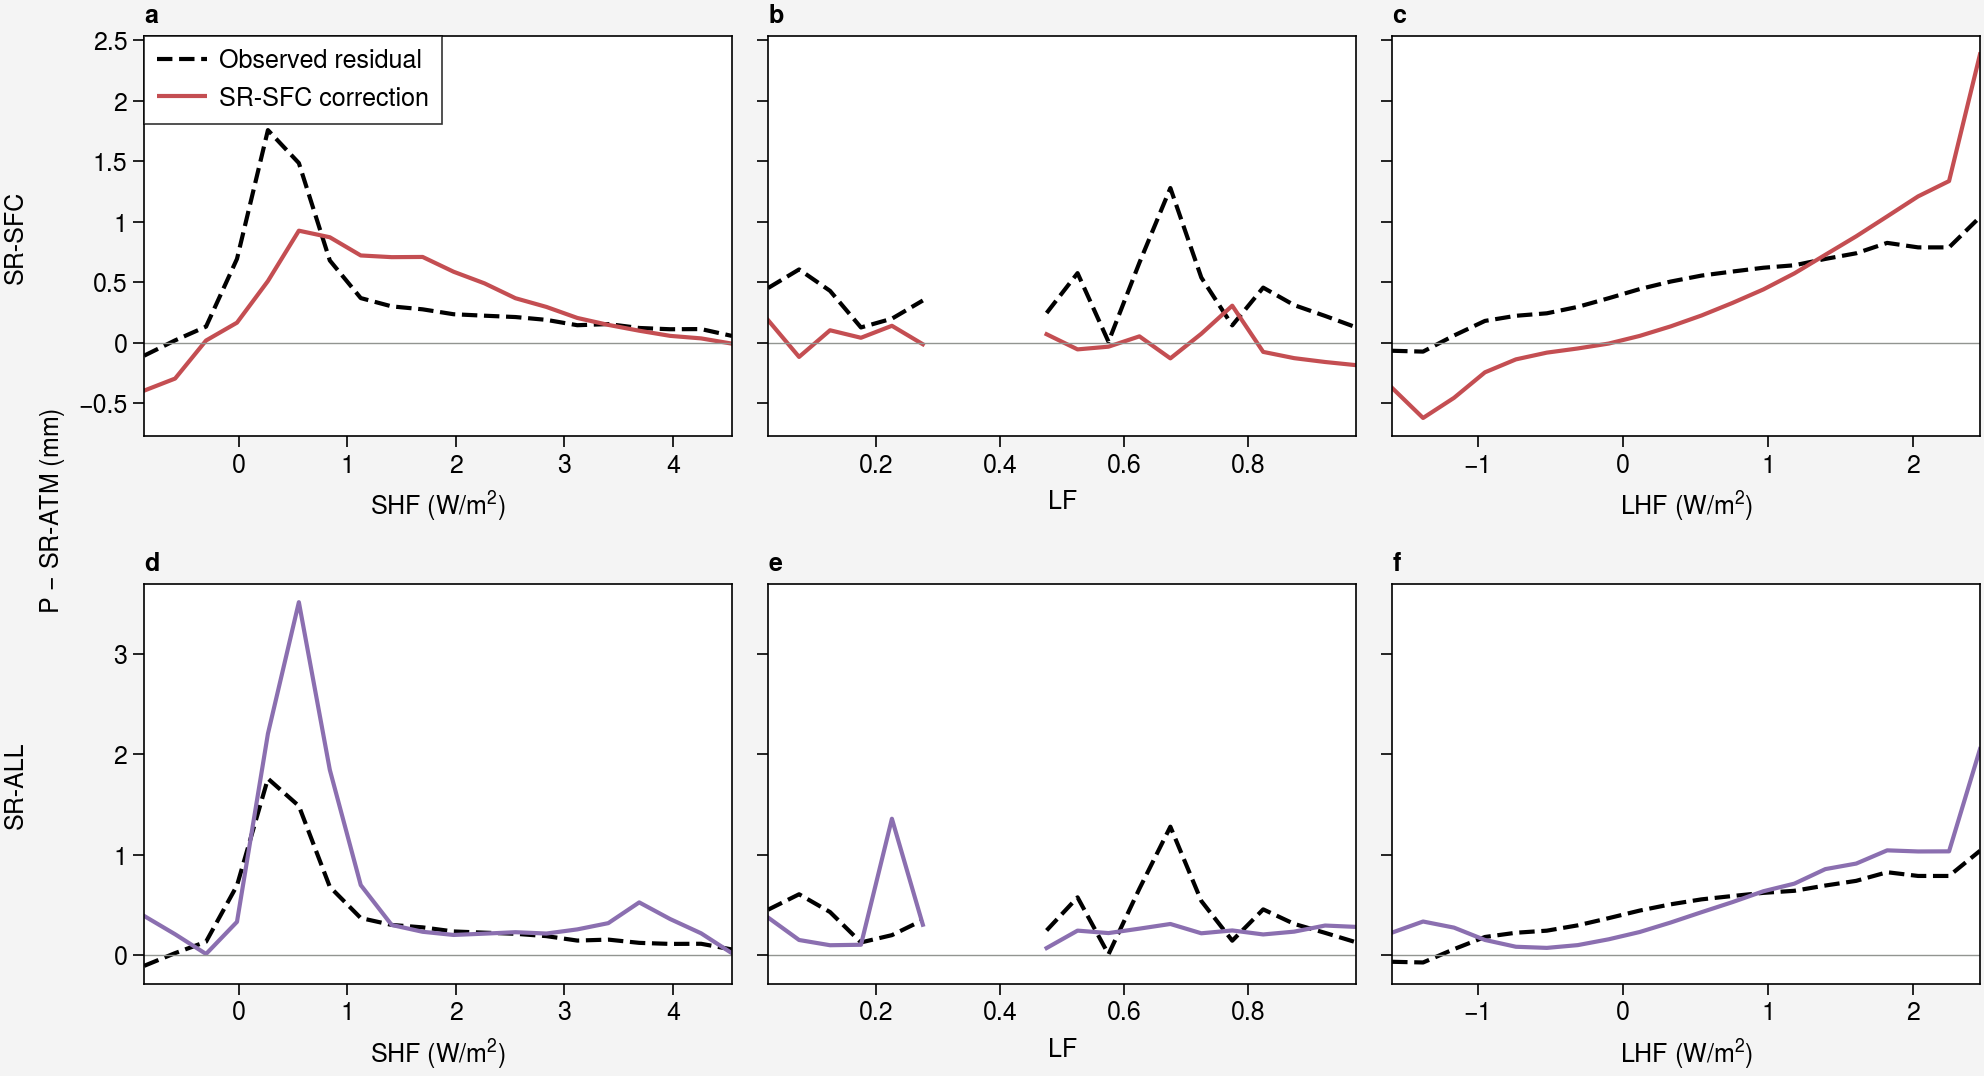

In [11]:
pred_atm = MODELPRED['sr_atm_eq']

models_with_sfc = [n for n in ORDER if n in ('sr_sfc_eq','sr_all_eq')]
fig,axs = pplt.subplots(nrows=len(models_with_sfc),ncols=3,figwidth=10,refheight=2,sharex=False,sharey=True)

sfcvars = [('shf',shf,'SHF (W/m$^2$)'),('lf',lf,'LF'),('lhf',lhf,'LHF (W/m$^2$)')]

for row,name in enumerate(models_with_sfc):
    residual = MODELPRED[name] - pred_atm
    obs_residual = obs - pred_atm
    for col,(varkey,varvals,varlabel) in enumerate(sfcvars):
        ax = axs[row,col]
        centers,obs_resid_mean,_ = bin_1d(varvals,obs_residual)
        _,pred_resid_mean,_ = bin_1d(varvals,residual)
        ax.plot(centers,obs_resid_mean,color='k',linewidth=1.5,linestyle='--',label='Observed residual')
        ax.plot(centers,pred_resid_mean,color=COLORS[name],linewidth=1.5,label=f'{LABELS[name]} correction')
        ax.axhline(0,color='gray',linewidth=0.5)
        ax.format(xlabel=varlabel,ylabel='P $-$ SR-ATM (mm)' if col==0 else None,grid=False)
        if row==0 and col==0:
            ax.legend(loc='ul',ncols=1)

axs.format(abc=True,titleloc='l',
           rowlabels=[LABELS[n] for n in models_with_sfc])
pplt.show()

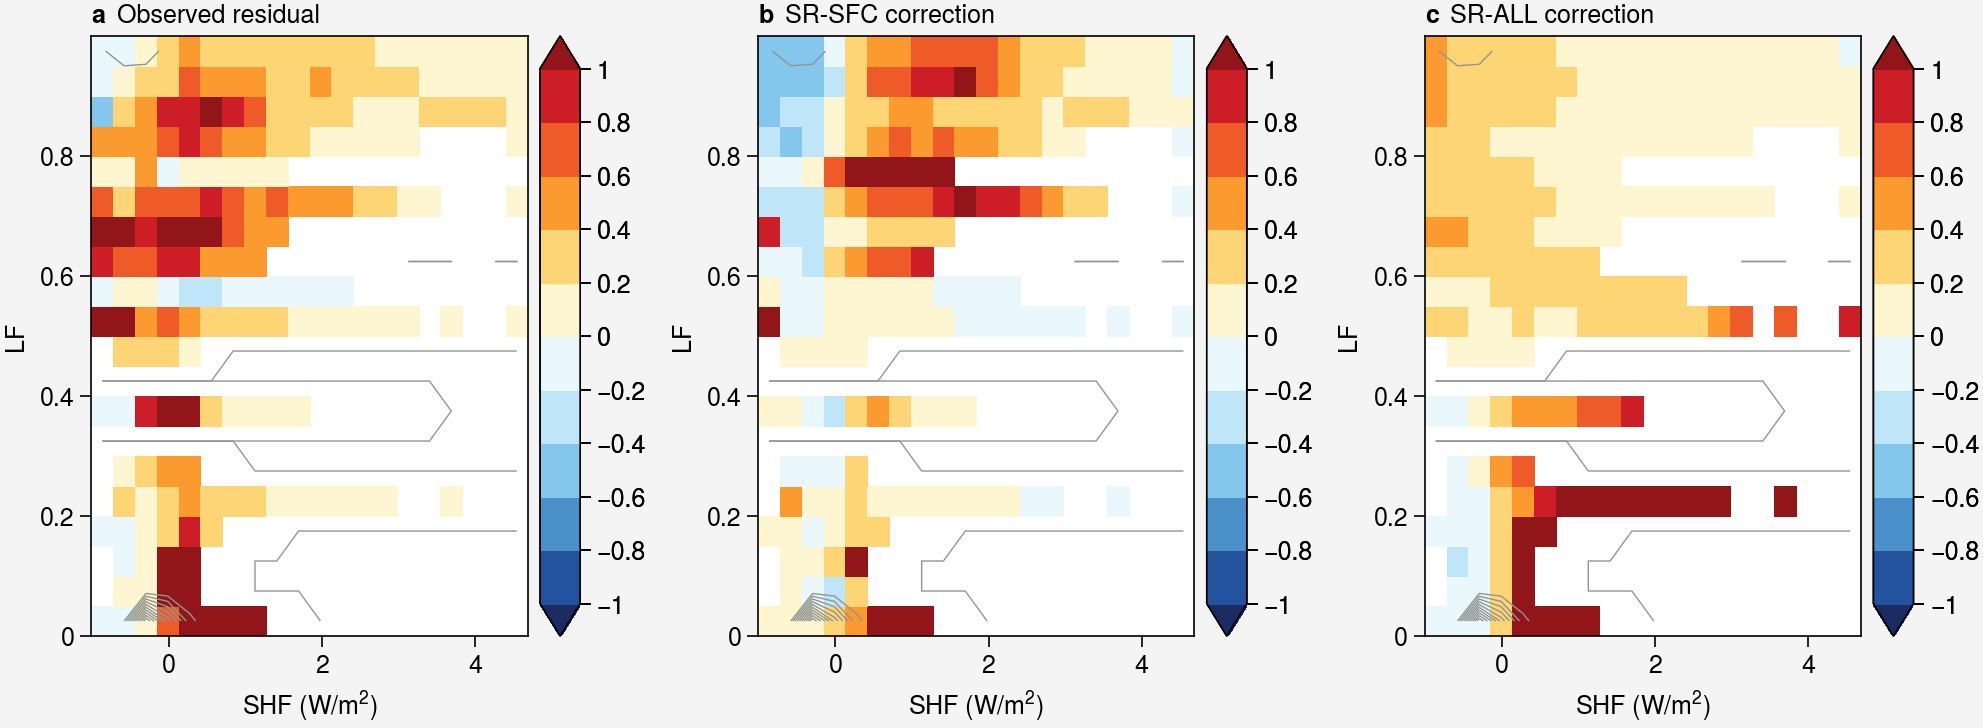

In [12]:
fig,axs = pplt.subplots(ncols=1+len(models_with_sfc),figwidth=10,refheight=3,share=False)
axs.format(grid=False,xlabel='SHF (W/m$^2$)',ylabel='LF')

xc,yc,obs_resid_2d,counts = bin_2d(shf,lf,obs-pred_atm,nbins=20)
m1 = axs[0].pcolormesh(xc,yc,obs_resid_2d.T,cmap='ColdHot',vmin=-1,vmax=1,extend='both')
axs[0].contour(xc,yc,counts.T,color='gray',linewidth=0.5)
axs[0].format(title='Observed residual')
axs[0].colorbar(m1,loc='r')

for i,name in enumerate(models_with_sfc):
    resid = MODELPRED[name] - pred_atm
    xc2,yc2,zm,cnt = bin_2d(shf,lf,resid,nbins=20)
    m = axs[i+1].pcolormesh(xc2,yc2,zm.T,cmap='ColdHot',vmin=-1,vmax=1,extend='both')
    axs[i+1].contour(xc2,yc2,cnt.T,color='gray',linewidth=0.5)
    axs[i+1].format(title=f'{LABELS[name]} correction')
    axs[i+1].colorbar(m,loc='r')

axs.format(abc=True,titleloc='l')
pplt.show()

### Surface correction spatial structure

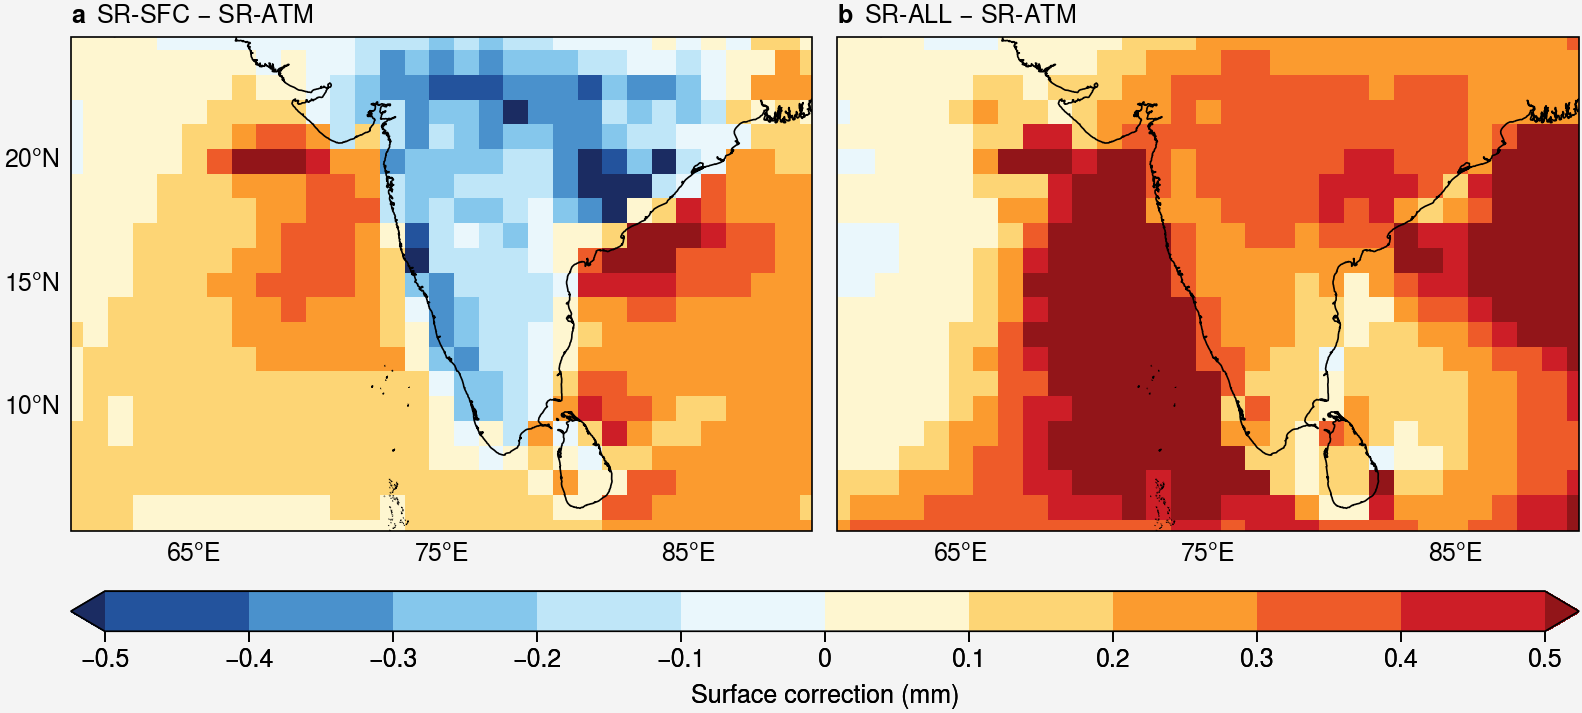

In [13]:
fig,axs = pplt.subplots(ncols=len(models_with_sfc),proj='cyl',figwidth=8,share=True)
axs.format(coast=True,latlim=LATRANGE,lonlim=LONRANGE,
           latlines=[10,15,20],lonlines=[65,75,85],grid=False)
axs[0].format(latlabels='l')
axs.format(lonlabels='b')

m = None
for i,name in enumerate(models_with_sfc):
    corr_full = np.full_like(obsraw,np.nan)
    corr_full[valid] = MODELPRED[name] - pred_atm
    corr_map = to_map(corr_full)
    m = axs[i].pcolormesh(lon,lat,corr_map,cmap='ColdHot',vmin=-0.5,vmax=0.5,extend='both')
    axs[i].format(title=f'{LABELS[name]} $-$ SR-ATM')

fig.colorbar(m,loc='b',label='Surface correction (mm)')
axs.format(abc=True,titleloc='l')
pplt.show()

## 4.5 Regime-Conditional Error Analysis
Where and when do models fail? Breakdown by land/ocean, month,
precipitation intensity quantile, and atmospheric regime.

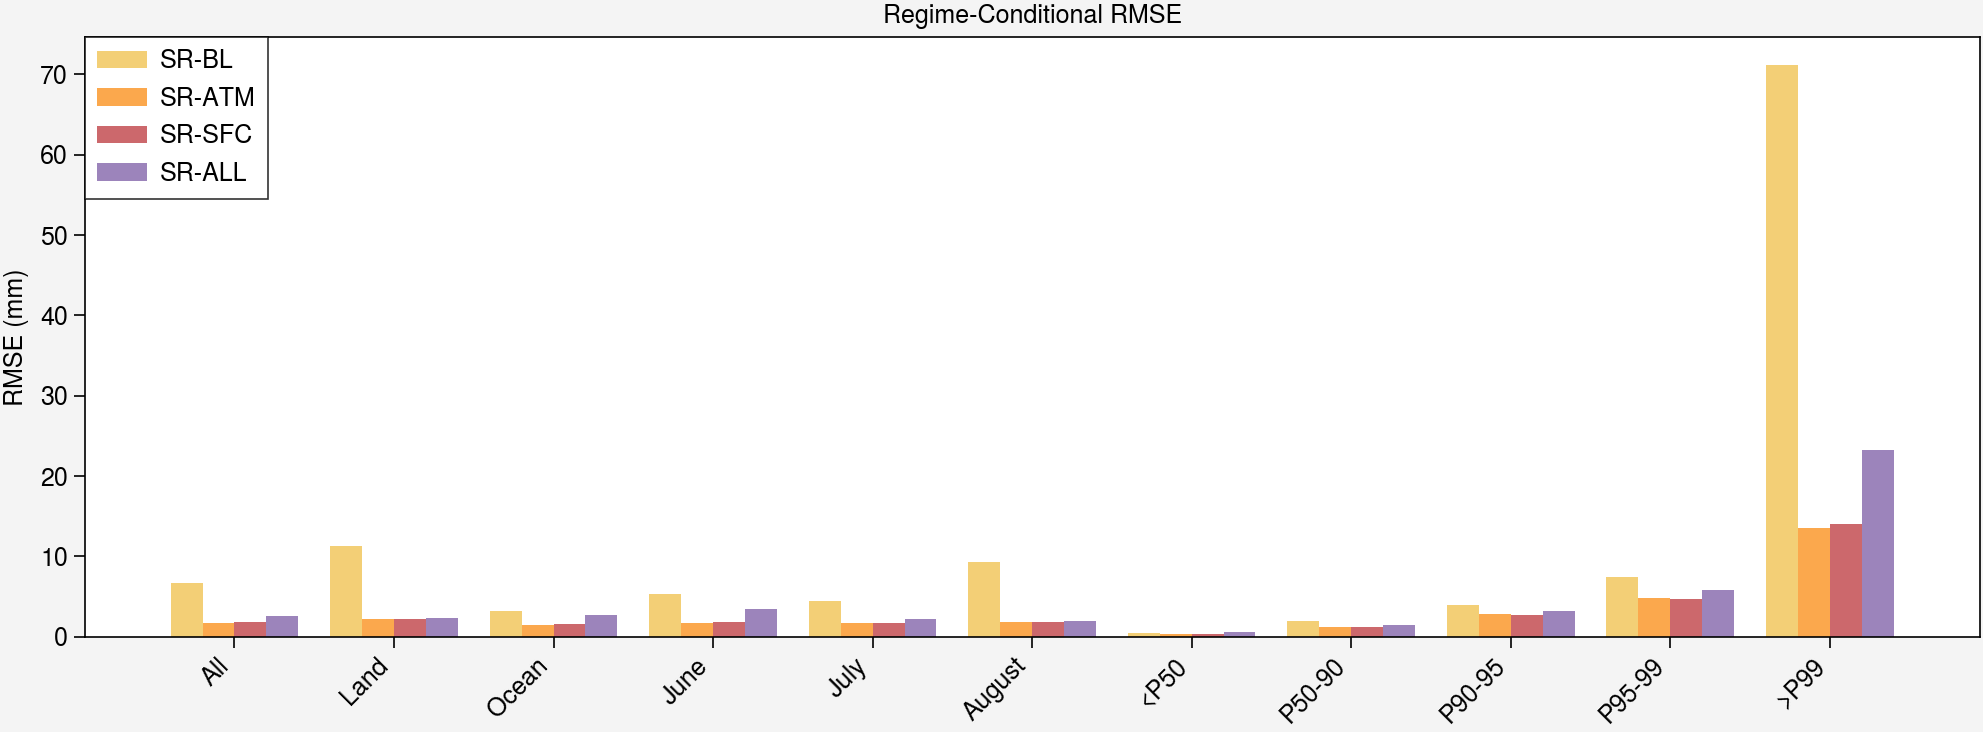

In [14]:
quantile_edges = [0,0.5,0.9,0.95,0.99,1.0]
quantile_labels = ['<P50','P50-90','P90-95','P95-99','>P99']
obs_quantiles = np.percentile(obs[obs>0],[50,90,95,99])

def assign_quantile_bin(p):
    out = np.zeros(len(p),dtype=int)
    out[p>obs_quantiles[0]] = 1
    out[p>obs_quantiles[1]] = 2
    out[p>obs_quantiles[2]] = 3
    out[p>obs_quantiles[3]] = 4
    return out

qbin = assign_quantile_bin(obs)

conditions = {
    'All':np.ones(len(obs),dtype=bool),
    'Land':landmask,
    'Ocean':oceanmask,
    'June':months==6,
    'July':months==7,
    'August':months==8}
for i,ql in enumerate(quantile_labels):
    conditions[ql] = qbin==i

condnames = list(conditions.keys())
barwidth = 0.8/len(ORDER)
xpos = np.arange(len(condnames))

fig,ax = pplt.subplots(figwidth=10,refheight=3)
for i,name in enumerate(ORDER):
    rmse_vals = []
    for cname in condnames:
        sel = conditions[cname]
        rmse_vals.append(np.sqrt(np.mean((obs[sel]-MODELPRED[name][sel])**2)))
    ax.bar(xpos+(i-(len(ORDER)-1)/2)*barwidth,rmse_vals,width=barwidth,
           color=COLORS[name],alpha=0.85,label=LABELS[name])

ax.format(grid=False,xticks=xpos,xticklabels=condnames,xrotation=45,
          ylabel='RMSE (mm)',title='Regime-Conditional RMSE')
ax.legend(loc='ul',ncols=1)
pplt.show()

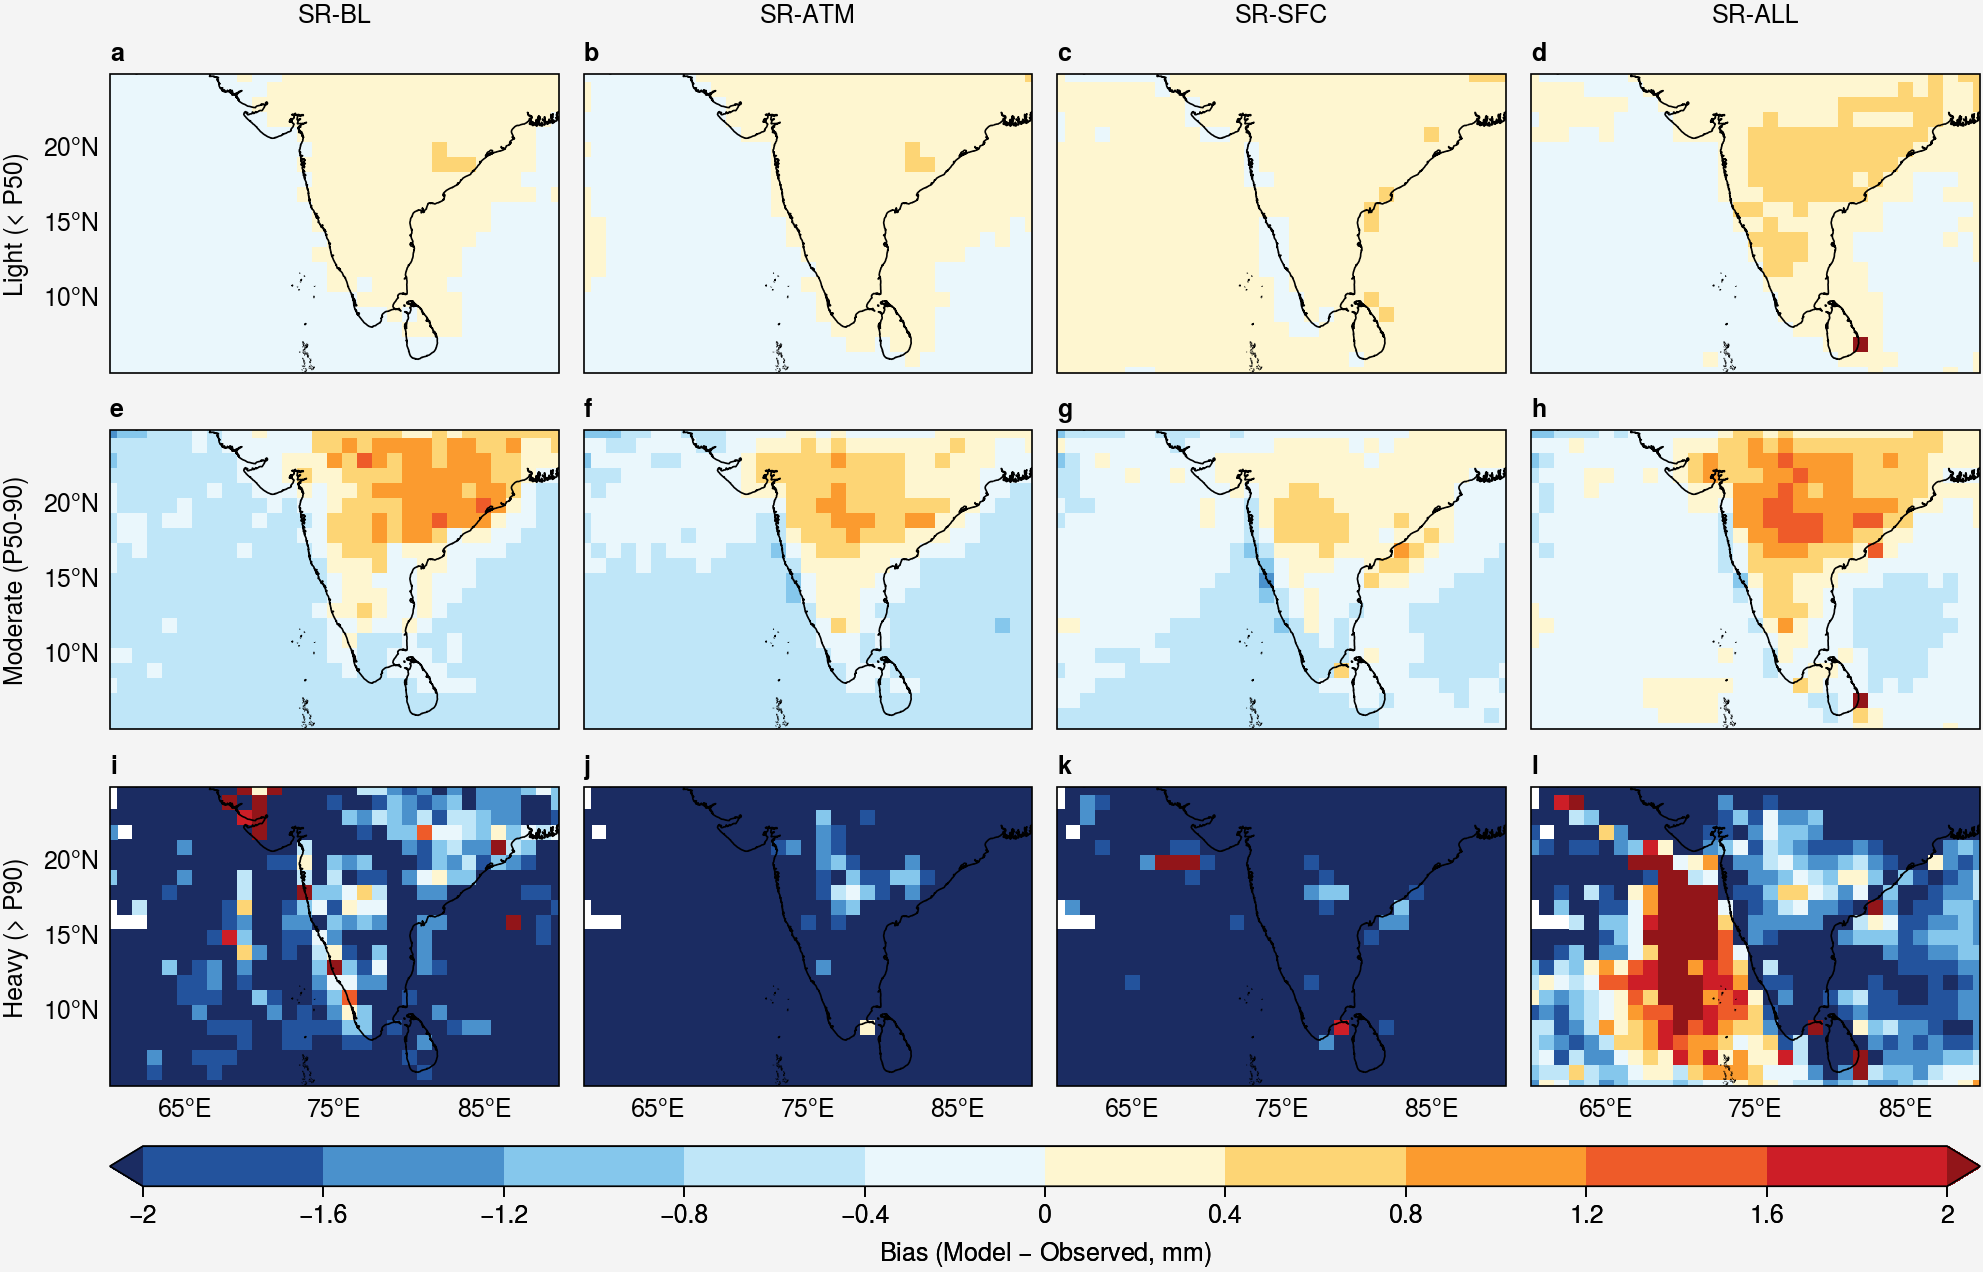

In [15]:
intensity_bins = {'Light (< P50)':qbin<=0,'Moderate (P50-90)':qbin==1,'Heavy (> P90)':qbin>=2}

fig,axs = pplt.subplots(nrows=len(intensity_bins),ncols=len(ORDER),proj='cyl',figwidth=10,share=True)
axs.format(coast=True,latlim=LATRANGE,lonlim=LONRANGE,
           latlines=[10,15,20],lonlines=[65,75,85],grid=False,
           collabels=[LABELS[n] for n in ORDER],
           rowlabels=list(intensity_bins.keys()))
axs[:,0].format(latlabels='l')
axs[-1,:].format(lonlabels='b')

m = None
for row,(bname,bmask) in enumerate(intensity_bins.items()):
    for col,name in enumerate(ORDER):
        bias_full = np.full_like(obsraw,np.nan)
        bias_full[valid] = np.where(bmask,MODELPRED[name]-obs,np.nan)
        bias_map = np.nanmean(bias_full.reshape(ntime,nlat,nlon),axis=0)
        m = axs[row,col].pcolormesh(lon,lat,bias_map,cmap='ColdHot',vmin=-2,vmax=2,extend='both')

fig.colorbar(m,loc='b',label='Bias (Model $-$ Observed, mm)')
axs.format(abc=True,titleloc='l')
pplt.show()

## 4.6 SR-BL: Buoyancy-Only Response
The simplest equation — how precipitation responds to the lower-tropospheric
buoyancy diagnostic.

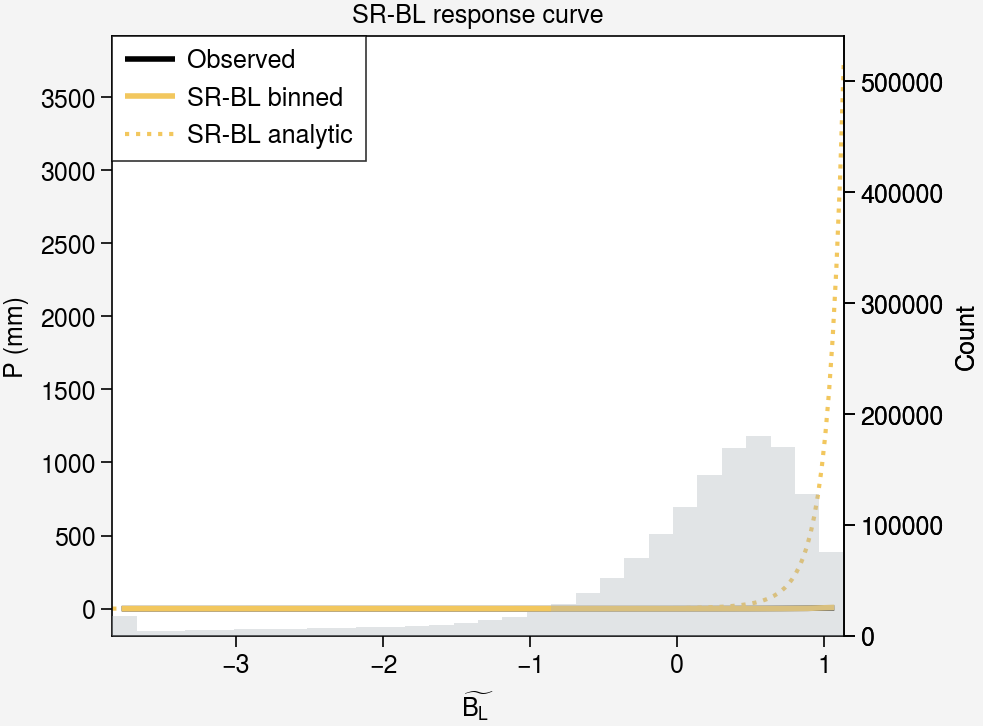

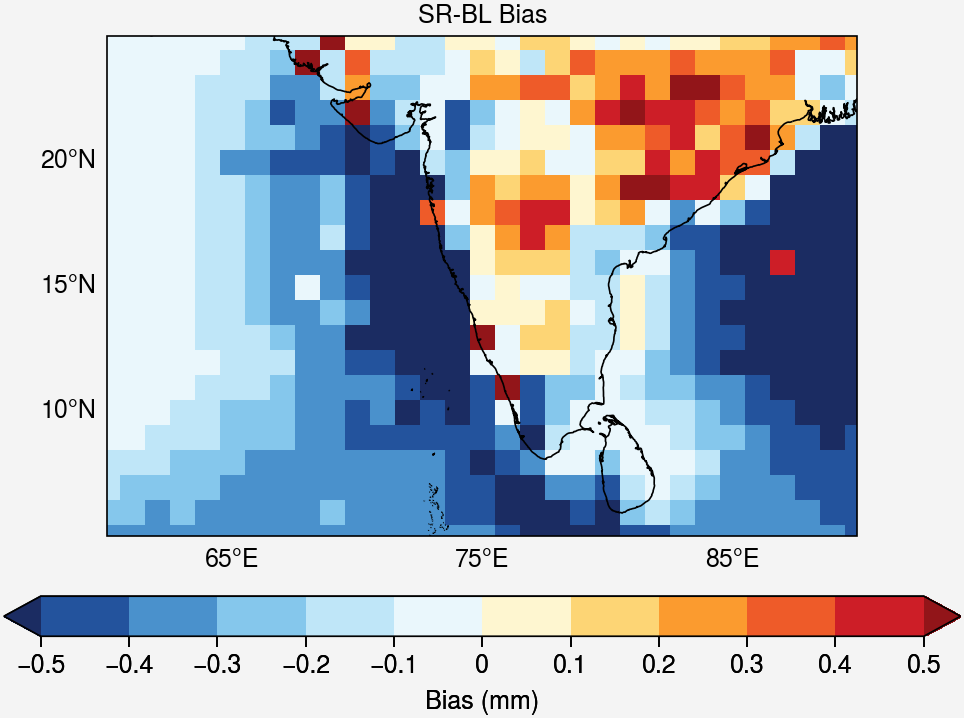

In [16]:
entry_bl = REGISTRY['sr_bl_eq']
cbl = entry_bl['constants']

bl_range = np.linspace(np.percentile(bl,1),np.percentile(bl,99),200)
bl_response = np.maximum(np.expm1((ZMIN + np.maximum((bl_range+cbl['a'])**3+cbl['b'],0.0))*STD+MEAN),0.0)

fig,ax = pplt.subplots(figwidth=5,refheight=3)
ax.format(grid=False)

centers,obsmean,counts = bin_1d(bl,obs,nbins=30)
_,predmean,_ = bin_1d(bl,MODELPRED['sr_bl_eq'],nbins=30)
ax.plot(centers,obsmean,color='k',linewidth=2,label='Observed')
ax.plot(centers,predmean,color=COLORS['sr_bl_eq'],linewidth=2,label='SR-BL binned')
ax.plot(bl_range,bl_response,color=COLORS['sr_bl_eq'],linewidth=1.5,linestyle=':',label='SR-BL analytic')
bx = ax.twinx()
bx.bar(centers,counts,width=centers[1]-centers[0],absolute_width=True,color='gray5',alpha=0.2)
bx.format(ylabel='Count',ylim=(0,counts.max()*3))
ax.format(xlabel=r'$\widetilde{\mathrm{B_L}}$',ylabel='P (mm)',title='SR-BL response curve')
ax.legend(loc='ul',ncols=1)
pplt.show()

bl_full = np.full_like(obsraw,np.nan)
bl_full[valid] = MODELPRED['sr_bl_eq'] - obs
bias_map = to_map(bl_full)
fig,ax = pplt.subplots(proj='cyl',figwidth=5,refheight=2.5)
ax.format(coast=True,latlim=LATRANGE,lonlim=LONRANGE,
          latlines=[10,15,20],lonlines=[65,75,85],grid=False,
          latlabels='l',lonlabels='b',title='SR-BL Bias')
m = ax.pcolormesh(lon,lat,bias_map,cmap='ColdHot',vmin=-0.5,vmax=0.5,extend='both')
fig.colorbar(m,loc='b',label='Bias (mm)')
pplt.show()

## 4.7 SR-ATM: Three-Variable Atmospheric Response
Detailed 2D slices showing how the cube-max structure responds to pairs
of atmospheric variables.

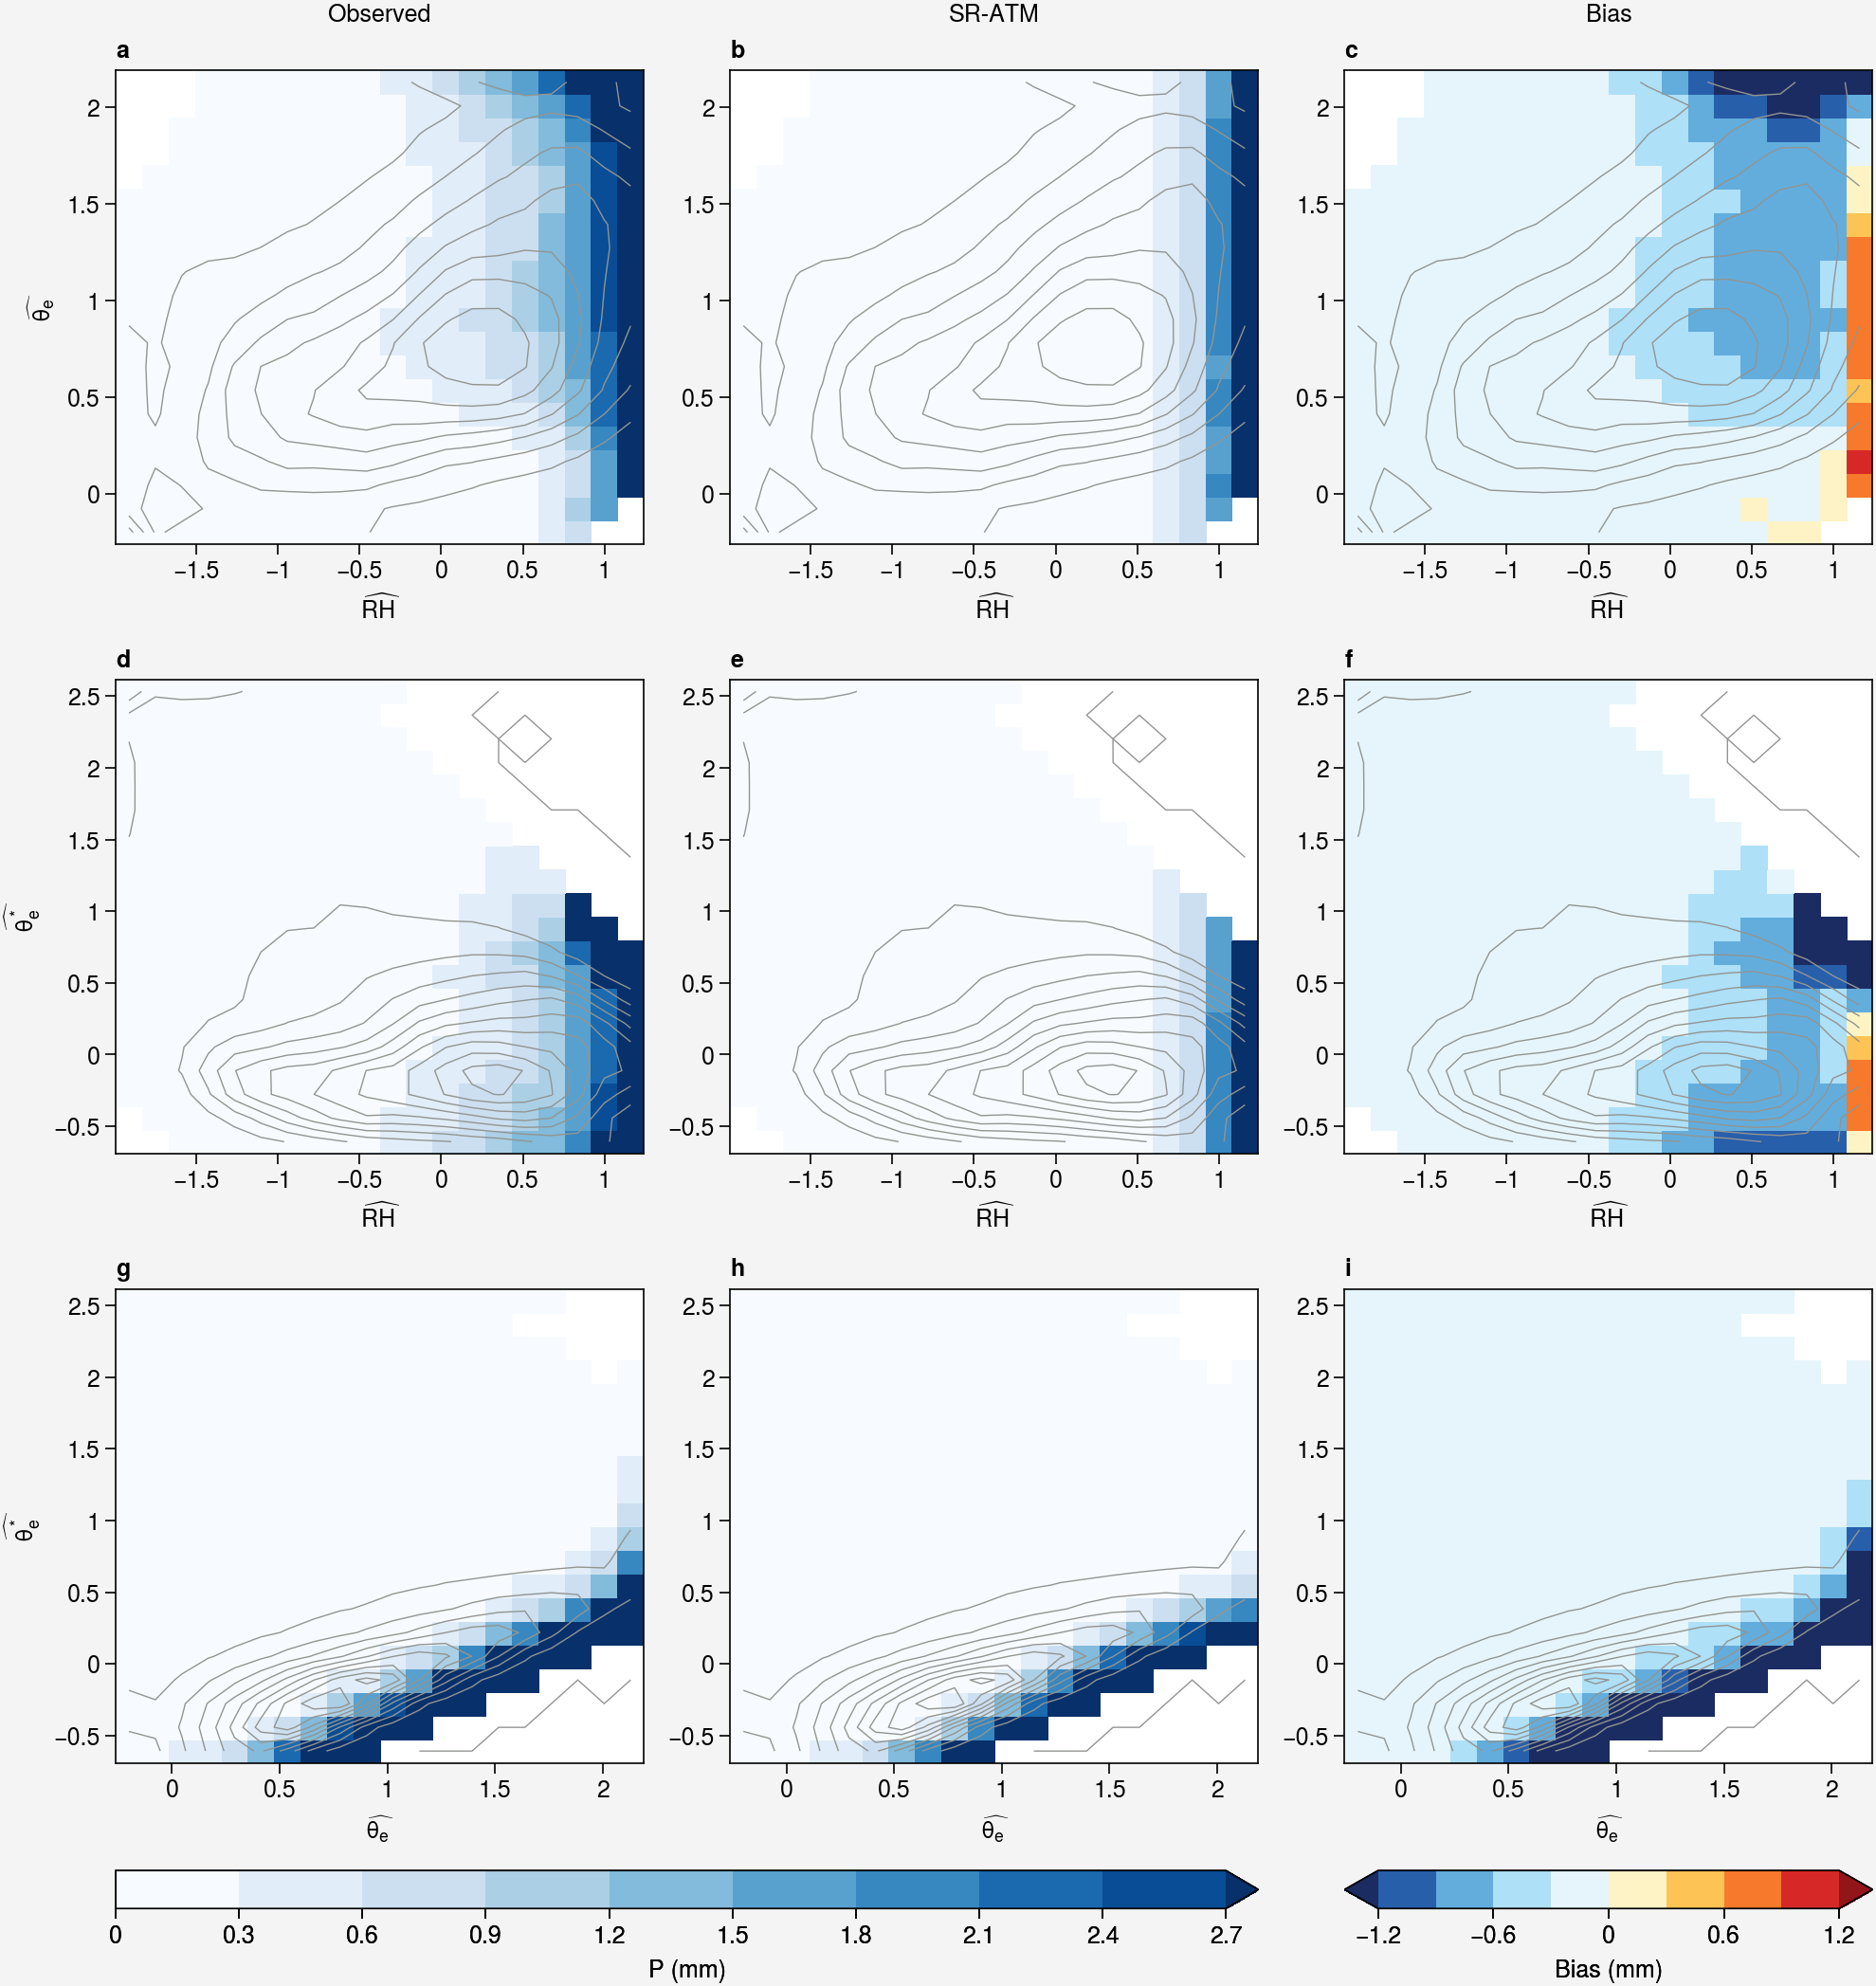

In [17]:
pairs = [('rh','thetae',r'$\widehat{\mathrm{RH}}$',r'$\widehat{\theta_e}$'),
         ('rh','thetaestar',r'$\widehat{\mathrm{RH}}$',r'$\widehat{\theta_e^*}$'),
         ('thetae','thetaestar',r'$\widehat{\theta_e}$',r'$\widehat{\theta_e^*}$')]

fig,axs = pplt.subplots(nrows=3,ncols=3,figwidth=10,refheight=2.5,share=False)
axs.format(grid=False,collabels=['Observed','SR-ATM','Bias'])

for row,(xkey,ykey,xlabel,ylabel) in enumerate(pairs):
    xvals,yvals = COLS[xkey],COLS[ykey]
    xc,yc,obsmean,counts = bin_2d(xvals,yvals,obs)
    _,_,predmean,_ = bin_2d(xvals,yvals,MODELPRED['sr_atm_eq'])
    bias = predmean - obsmean

    m1 = axs[row,0].pcolormesh(xc,yc,obsmean.T,cmap='Blues',vmin=0,vmax=3,extend='max')
    axs[row,0].contour(xc,yc,counts.T,color='gray',linewidth=0.5)
    m2 = axs[row,1].pcolormesh(xc,yc,predmean.T,cmap='Blues',vmin=0,vmax=3,extend='max')
    axs[row,1].contour(xc,yc,counts.T,color='gray',linewidth=0.5)
    m3 = axs[row,2].pcolormesh(xc,yc,bias.T,cmap='ColdHot',vmin=-1.5,vmax=1.5,extend='both')
    axs[row,2].contour(xc,yc,counts.T,color='gray',linewidth=0.5)
    axs[row,0].format(ylabel=ylabel)
    axs[row,:].format(xlabel=xlabel)

fig.colorbar(m1,loc='b',col=(1,2),label='P (mm)')
fig.colorbar(m3,loc='b',col=3,label='Bias (mm)')
axs.format(abc=True,titleloc='l')
pplt.show()

## 4.8 Model Hierarchy Summary
How much does each layer of complexity add? Variance explained
by the atmospheric baseline, surface correction, and combined model.

In [18]:
r2_all   = {name:get_r2(obs,MODELPRED[name]) for name in ORDER}
r2_land  = {name:get_r2(obs[landmask],MODELPRED[name][landmask]) for name in ORDER}
r2_ocean = {name:get_r2(obs[oceanmask],MODELPRED[name][oceanmask]) for name in ORDER}

fig,axs = pplt.subplots(ncols=3,figwidth=10,refheight=2.5,sharey=True)
axs.format(grid=False,ylabel=r'$R^2$',ylim=(0,0.7),yticks=0.1)

for ax,r2dict,title in zip(axs,[r2_all,r2_land,r2_ocean],['All','Land','Ocean']):
    modelpos = np.arange(len(ORDER))
    ax.bar(modelpos,[r2dict[n] for n in ORDER],color=[COLORS[n] for n in ORDER],alpha=0.85)
    for i,name in enumerate(ORDER):
        ax.text(i,r2dict[name]+0.01,f'{r2dict[name]:.3f}',ha='center',va='bottom',fontsize=7)
    ax.format(xticks=modelpos,xticklabels=[LABELS[n] for n in ORDER],xrotation=30,title=title)

axs.format(abc=True,titleloc='l')
pplt.show()

print('\nR² summary:')
print(f'{"Model":<10} {"All":>8} {"Land":>8} {"Ocean":>8}')
for name in ORDER:
    print(f'{LABELS[name]:<10} {r2_all[name]:>8.4f} {r2_land[name]:>8.4f} {r2_ocean[name]:>8.4f}')

LinAlgError: Singular matrix

Figure(nrows=1, ncols=3, refheight=2.5, figwidth=10.0)


R² summary:
Model           All     Land    Ocean
SR-BL       -9.5412 -18.5859  -2.1208
SR-ATM       0.2696   0.2184   0.3022
SR-SFC       0.2611   0.2285   0.2780
SR-ALL      -0.6146   0.1412  -1.2699
